# Requirements figure: dark-matter reach versus astrometric capability

Produces **`figs/requirements.pdf`** (Fig. 9 of the paper), for **both** benchmark
systems on one set of axes.

Peak acceleration-channel SNR evaluated along the fiducial $\Lambda$CDM
$\rho_s(M_\mathrm{L})$ prediction (the dashed relation of `figs/SNR.pdf`), versus
the per-epoch relative astrometric precision $\sigma_{\delta\theta}$, for the
fiducial $\tau = 10\,$yr, $N = 300$ campaign. Vertical bands mark representative
current and planned astrometric capabilities.

Three curves:

- **B1422+231 (galaxy lens), with stellar residual** --- includes the worst-case
  post-subtraction stellar microlensing residual of Sec. III C: the unfitted-star
  bound plus the fitted-star subtraction residual, evaluated at image A (the case
  studied in the companion paper, rescaled to the survey parameters here) and
  doubled for the differential pair. The per-epoch precision tracks the
  intensity-interferometric fit quality, so the instrumental floor and the
  fitted-star residual both scale as $\sigma_{\delta\theta}^2$, while the
  unfitted-star bound scales as $\sigma_{\delta\theta}^3$ (via
  $\theta_\mathrm{fit} \propto \sigma_{\delta\theta}^{-1/2} N^{1/4}$):

  $$\mathrm{SNR} = \frac{S_\mathrm{CDM}}{(\mathrm{instr} + 2\,\mathrm{fitted}_A)\,s^2 + 2\,\mathrm{unfitted}_A\,s^3}, \qquad s = \frac{\sigma_{\delta\theta}}{0.1\,\mu\mathrm{as}}.$$

- **B1422+231, certified clean / limits** --- instrument-limited reach
  ($\mathrm{SNR} \propto \sigma_{\delta\theta}^{-2}$) for certifiably star-free
  epochs and images, and for upper limits.

- **SDSS J1029+2623 (cluster lens)** --- the stellar background is negligible
  ($\kappa_* \approx 0.003$), so only the instrumental scaling applies.

**Inputs.** This notebook is a thin, fast summary layer: the signal and noise
budget at the reference precision is computed in `sensitivity.ipynb` (both parts)
and `impact_numbers.py`, and is hard-coded below with provenance comments. Change
those numbers here only in step with a re-run of `sensitivity.ipynb`.

*Runtime: seconds.*

## Setup and budget inputs

In [1]:
from preamble import *

colors = sns.color_palette(xgfs_fancy6)

# ---- galaxy lens B1422+231, at the reference sigma_delta_theta = 0.1 muas ----
# CDM-curve peak signal (best pair, A,B) at M_L = 9.7e-5 Msun (impact_numbers.py), muas^2/yr^4
# [2026-07 kinematics fix: bulk-only macro-image sweep; internal dispersion unmagnified]
S_CDM = 3.17e-5
# noise budget at sigma = 0.1 muas [muas^2/yr^4]: instrumental floor and the image-A
# stellar residual (fitted / unfitted), the latter doubled for the differential pair
instr = 2.4e-6
fitted_A = 8.83e-6
unfitted_A = 3.7e-6
SNR_B1422_clean = 13.2     # instrument-limited (certified clean), sigma = 0.1 muas

# ---- cluster lens SDSS J1029+2623, at the reference sigma_delta_theta = 1 muas ----
SNR_J1029_at_1p0 = 0.67    # f_sub = 0.5 (impact_numbers.py; v_eff = 552 km/s incl.
                           # moving-clump member-halo term, f_gal = 0.2)

## SNR versus precision

In [2]:
sig = np.logspace(-2, 3, 400)   # muas
s = sig / 0.1
snr_B_star = S_CDM / ((instr + 2*fitted_A)*s**2 + 2*unfitted_A*s**3)
snr_B_clean = SNR_B1422_clean * (0.1/sig)**2
snr_J = SNR_J1029_at_1p0 * (1.0/sig)**2

# thresholds where SNR = 1
sig_B_star = sig[np.argmin(np.abs(snr_B_star - 1))]
sig_B_clean = 0.1*np.sqrt(SNR_B1422_clean)
sig_J1 = 1.0*np.sqrt(SNR_J1029_at_1p0)
print('SNR=1 thresholds: B1422 %.3f muas (with stellar) | %.2f muas (clean) | J1029 %.2f muas'
      % (sig_B_star, sig_B_clean, sig_J1))
print('SNR at fiducial 0.1 muas, with stellar: %.2f' % snr_B_star[np.argmin(np.abs(sig-0.1))])
print('SNR at 0.03 muas, with stellar: %.2f' % snr_B_star[np.argmin(np.abs(sig-0.03))])

SNR=1 thresholds: B1422 0.107 muas (with stellar) | 0.36 muas (clean) | J1029 0.82 muas
SNR at fiducial 0.1 muas, with stellar: 1.14
SNR at 0.03 muas, with stellar: 15.88


## Figure  →  `figs/requirements.pdf`

saved ../figs/requirements.pdf


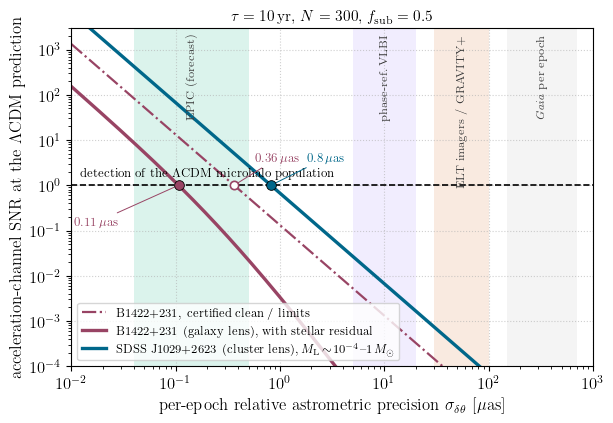

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6.3, 4.4))

# capability bands (representative per-epoch relative astrometric precision)
bands = [
    (0.04, 0.5,  r'EPIC (forecast)',                colors[5]),
    (5,    20,   r'phase-ref.\ VLBI',               colors[1]),
    (30,   100,  r'ELT imagers / GRAVITY$+$',       colors[2]),
    (150,  700,  r'\textit{Gaia} per epoch',        colors[6]),
]
for lo, hi, lab, c in bands:
    ax.axvspan(lo, hi, color=c, alpha=0.22, lw=0)
    ax.text(np.sqrt(lo*hi), 2.2e3, lab, rotation=90, fontsize=8.5,
            ha='center', va='top', color=(0.25, 0.25, 0.25))

ax.plot(sig, snr_B_clean, color=colors[4], lw=1.6, ls='dashdot',
        label=r'B1422$+$231, certified clean / limits')
ax.plot(sig, snr_B_star, color=colors[4], lw=2.4,
        label=r'B1422$+$231 (galaxy lens), with stellar residual')
ax.plot(sig, snr_J, color=colors[3], lw=2.4,
        label=r'SDSS J1029$+$2623 (cluster lens), $M_\mathrm{L}\!\sim\!10^{-4}$--$1\,M_\odot$')

ax.axhline(1, color='k', lw=1.2, ls='dashed')
ax.text(1.2e-2, 1.35, r'detection of the $\Lambda$CDM microhalo population', fontsize=9,
        ha='left', va='bottom', color='k')

for x, c in [(sig_B_star, colors[4]), (sig_J1, colors[3])]:
    ax.plot([x], [1], marker='o', ms=7, color=c, mec='k', mew=0.6, zorder=5)
ax.plot([sig_B_clean], [1], marker='o', ms=6, color='w', mec=colors[4], mew=1.2, zorder=5)
ax.annotate(r'$%.1f\,\mathrm{\mu as}$' % sig_J1, xy=(sig_J1, 1), xytext=(sig_J1*2.2, 3.4),
            fontsize=9, color=colors[3], ha='left',
            arrowprops=dict(arrowstyle='-', color=colors[3], lw=0.7))
ax.annotate(r'$%.2f\,\mathrm{\mu as}$' % sig_B_star, xy=(sig_B_star, 1), xytext=(sig_B_star/10, 0.13),
            fontsize=9, color=colors[4], ha='left',
            arrowprops=dict(arrowstyle='-', color=colors[4], lw=0.7))
ax.annotate(r'$%.2f\,\mathrm{\mu as}$' % sig_B_clean, xy=(sig_B_clean, 1), xytext=(sig_B_clean*1.6, 3.4),
            fontsize=9, color=colors[4], ha='left',
            arrowprops=dict(arrowstyle='-', color=colors[4], lw=0.7))

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(1e-2, 1e3); ax.set_ylim(1e-4, 3e3)
ax.set_xlabel(r'per-epoch relative astrometric precision $\sigma_{\delta\theta}~[\mathrm{\mu as}]$')
ax.set_ylabel(r'acceleration-channel SNR at the $\Lambda$CDM prediction')
ax.legend(loc='lower left', fontsize=8.6, frameon=True)
ax.set_title(r'$\tau = 10\,\mathrm{yr}$, $N = 300$, $f_\mathrm{sub} = 0.5$', fontsize=11)
ax.grid(ls='dotted', alpha=0.6)

fig.tight_layout()
fig.savefig('../figs/requirements.pdf', bbox_inches='tight')
print('saved ../figs/requirements.pdf')
plt.show()